In [3]:
import os
os.getcwd()

'C:\\Users\\polua'

In [5]:
os.getcwd()

'C:\\Users\\polua'

In [6]:
import os

os.chdir(r"D:\OIBSIP\archive (2)")

In [7]:
os.getcwd()

'D:\\OIBSIP\\archive (2)'

In [8]:
# EDA on Retail Sales Data

## OASIS INFOBYTE — Data Analytics Task 1

### Objective
#To perform Exploratory Data Analysis (EDA) on retail sales data to identify sales patterns, customer behaviour, product trends, and actionable business insights.

### Tools Used
#- Python
#- Pandas
#- NumPy
#- Matplotlib
#- Jupyter Notebook

In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#load dataset
df = pd.read_csv(r"D:\OIBSIP\archive (2)\retail_sales_dataset.csv")

In [16]:
#first 5 rows 
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [17]:
# last  5 rows
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [18]:
#check the dat size 
df.shape

(1000, 9)

In [19]:
#check the column data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [20]:
#checking missing values 
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [25]:
#Check the duplicated  check 
df.duplicated().sum()

np.int64(0)

In [28]:
#convert the  date  column
df["Date"] = pd.to_datetime(df["Date"])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [31]:
#descriptive statistics 
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [32]:
#calculate the mean 
df.mean(numeric_only =True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [33]:
#calculate teh median
df.median(numeric_only = True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [36]:
#Checking teh mode 
df.mode(numeric_only=True).iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [38]:
#Standard deviation
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [41]:
#Monthly Sales Trend
df["Month"]=df["Date"].dt.to_period("M")

In [43]:
#calculate the  total sales by month
monthly_sales = df.groupby("Month")["Total Amount"].sum()

In [45]:
monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

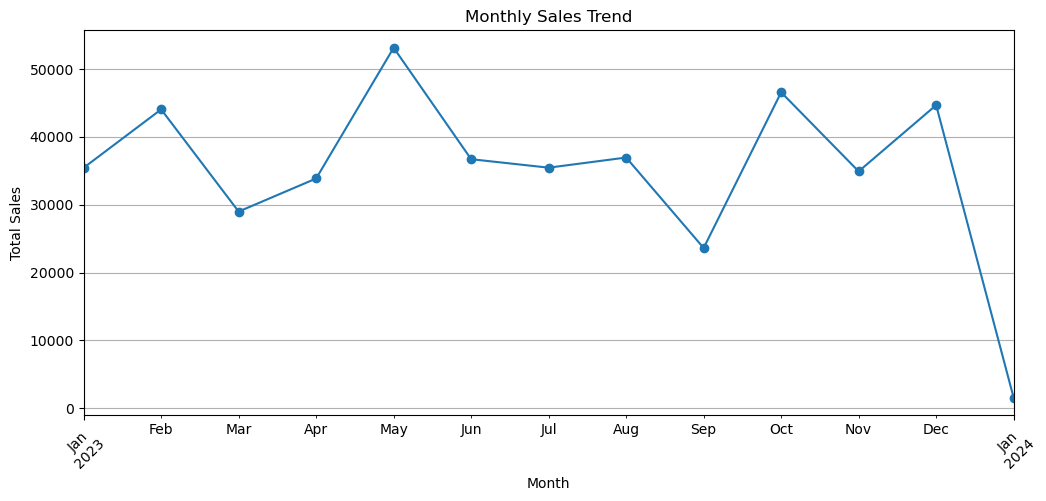

In [52]:
#Create monthly sales  chart
plt.figure(figsize=(12,5))
monthly_sales.plot(kind="line",marker = "o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [53]:
#Quarterly Sales Analysis. 
df["Quarter"] = df["Date"].dt.quarter

In [54]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

In [56]:
quarterly_sales

Quarter
1    110030
2    123735
3     96045
4    126190
Name: Total Amount, dtype: int64

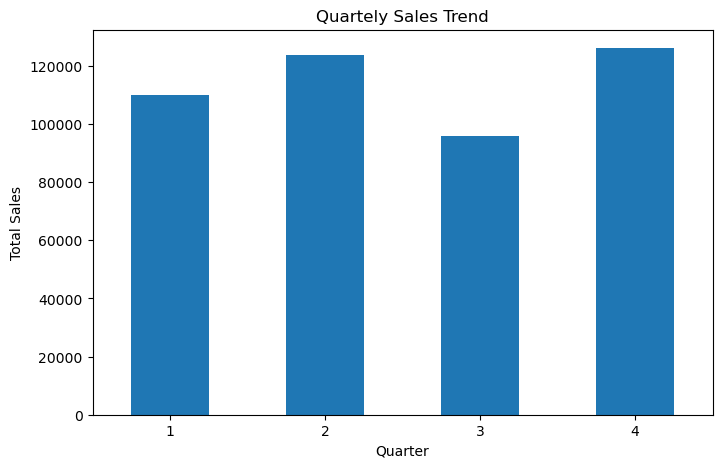

In [62]:
#Quarterly Sales Chart
plt.figure(figsize=(8,5))
quarterly_sales.plot(kind="bar")
plt.title("Quartely Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


In [63]:
#Product Category Analysis
category_sales = df.groupby("Product Category")["Total Amount"].sum()

In [64]:
category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

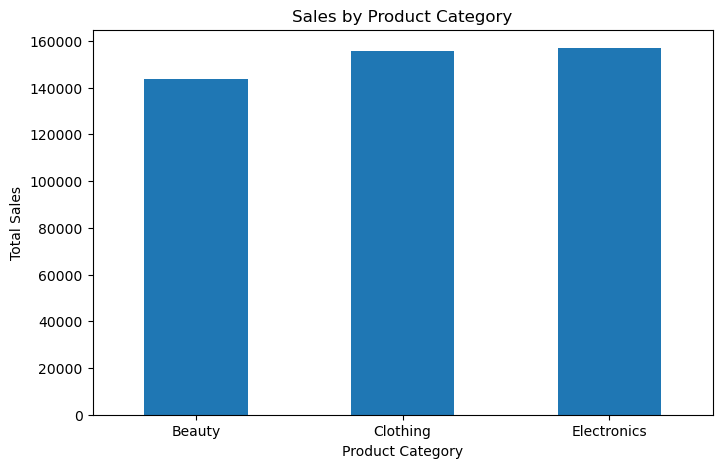

In [71]:
#Product Category Sales Chart
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


In [72]:
#Gender Analysis
gender_sales = df.groupby("Gender")["Total Amount"].sum()

In [73]:
gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

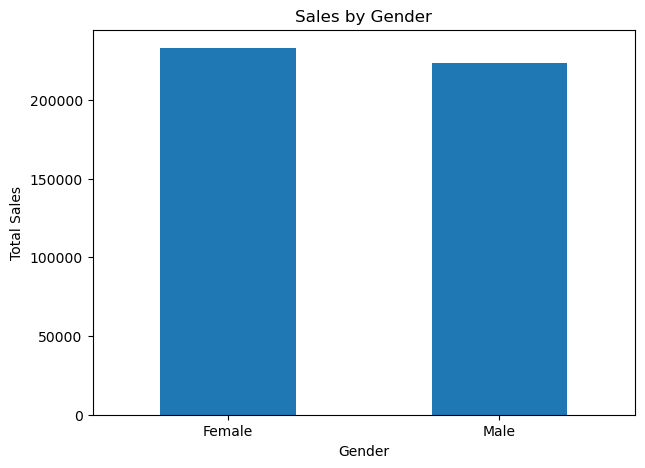

In [78]:
plt.figure(figsize=(7,5))
gender_sales.plot(kind="bar")
plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


In [79]:
#Age Group Analysis
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

In [80]:
age_group_sales = df.groupby("Age Group", observed=True)["Total Amount"].sum()

In [82]:
age_group_sales

Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-65     80410
Name: Total Amount, dtype: int64

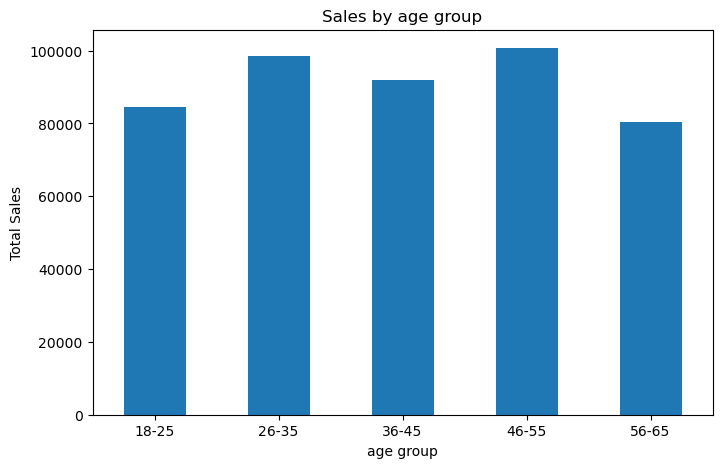

In [84]:
plt.figure(figsize=(8,5))
age_group_sales.plot(kind="bar")
plt.title("Sales by age group")
plt.xlabel("age group")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


In [85]:
#Customer Analysis
category_count = df["Product Category"].value_counts()

In [86]:
category_count

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

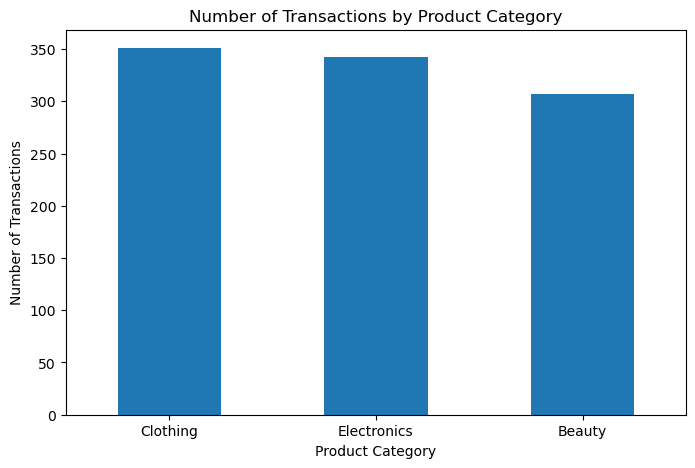

In [87]:
#Transaction Count Chart
plt.figure(figsize=(8, 5))

category_count.plot(kind="bar")

plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [88]:
#Correlation Analysis
correlation = df.corr(numeric_only=True)

In [89]:
correlation

,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Quarter
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034,0.038435
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568,-0.000837
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707,-0.020411
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925,-0.005834
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000,-0.001605
Quarter,0.038435,-0.000837,-0.020411,-0.005834,-0.001605,1.000000


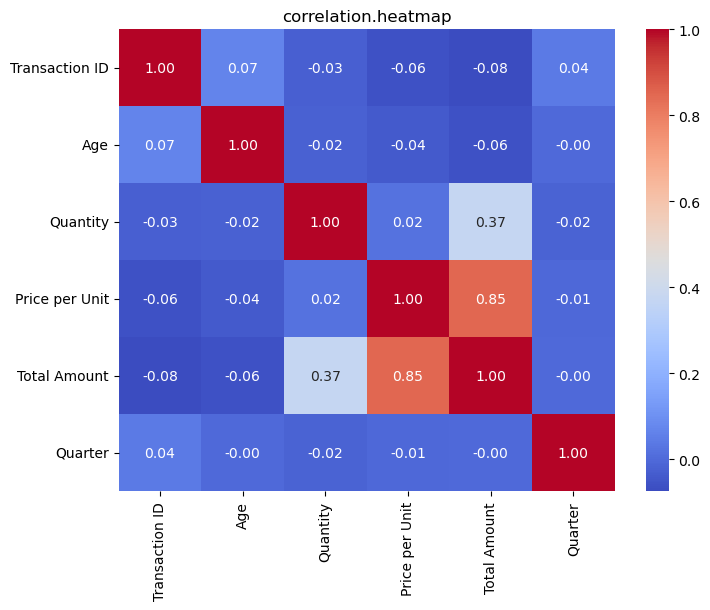

In [93]:
#heat map 
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot =True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("correlation.heatmap")
plt.show()
    
    


In [94]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Quarter', 'Age Group'],
      dtype='object')

In [95]:
top_categories = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

In [96]:
top_categories

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

In [98]:
avg_sales_category = df.groupby("Product Category")["Total Amount"].mean()

In [99]:
avg_sales_category

Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64

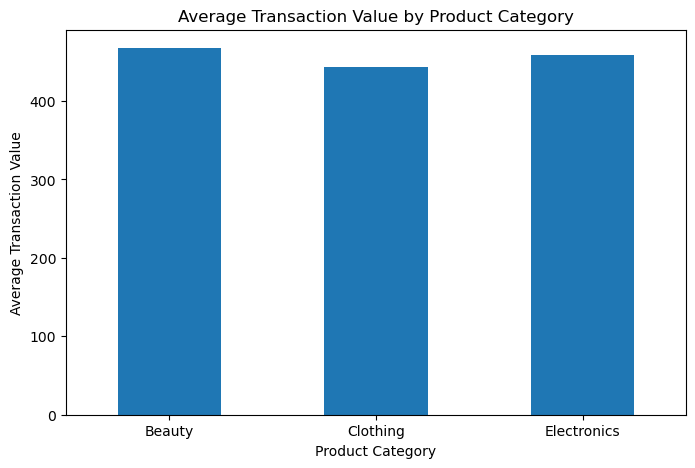

In [100]:
plt.figure(figsize=(8, 5))

avg_sales_category.plot(kind="bar")

plt.title("Average Transaction Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=0)
plt.show()

In [102]:
## Business Recommendations

#1. Focus on Electronics and Clothing because they generate the highest total sales. The business should maintain sufficient inventory and promote these categories during high-demand periods.

#2. Target customers aged 46–55 with personalized offers because this age group generated the highest sales.

#3. Increase the average transaction value of Clothing through bundle offers and cross-selling because Clothing has the highest number of transactions but the lowest average transaction value.

#4. Use high-performing months and quarters to plan promotions and inventory more effectively.

In [103]:
## Conclusion

#The exploratory data analysis identified important patterns in the retail sales dataset. Q4 generated the highest quarterly sales, while Electronics produced the highest total revenue. Clothing recorded the highest number of transactions, and customers aged 46–55 generated the highest sales.

#The findings can help improve inventory planning, customer targeting, promotional strategies, and category-level sales performance.

In [104]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,4,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,1,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,1,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2,26-35


In [105]:
df.shape

(1000, 12)